# Greek Calamari: crops, GT, and why exact match is 0%

Finetuned `lstm_3/lr0001/best.pt` reports about **15% CER** on the Greek finetuning split, but **0% exact match**. That is expected from the metric definitions, not a broken decoder.

- **CER** is character edits / characters. A 50-character line at 15% CER still has ~7 wrong characters.
- **Exact match** is 1 only when the whole line is identical. One accent, one middle-dot, or one `ο`/`o` miss and the line scores 0.
- Finetuning lines are long: val mean **50.9** characters, test mean **50.2**. On 19+21 lines, errors do not have to concentrate on a few disasters — they can sit on every line.

This notebook loads the same checkpoint, prints corpus CER vs exact match, then shows **where** the remaining 15% lives (diacritics, punctuation, Latin lookalikes, real letter errors).

Default paths:
- Checkpoint: `checkpoints/calamari/finetuned/on_greek/lstm_3/lr0001/best.pt`
- Finetuning data: `data/processed/greek/finetuning`
- Pretraining data (GT catalog only): `data/processed/greek/pretraining`


In [2]:
from __future__ import annotations

import sys
import unicodedata
from collections import Counter
from html import escape
from pathlib import Path

import torch
from IPython.display import HTML, Image as IPyImage, display
from PIL import Image as PILImage


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not locate the greek-ocr repo root.")


REPO = find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.inference.calamari import _load_image
from src.metrics.metrics import compute_text_metrics, edit_distance
from src.models.calamari.checkpoint import load_calamari_checkpoint
from src.models.calamari.codec import CharacterCodec

CHECKPOINT = (
    REPO
    / "checkpoints"
    / "calamari"
    / "finetuned"
    / "on_greek"
    / "lstm_3"
    / "lr0001"
    / "best.pt"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, metadata = load_calamari_checkpoint(CHECKPOINT)
model = model.to(device).eval()
codec = CharacterCodec(metadata.charset)

print(f"Repo:        {REPO}")
print(f"Checkpoint:  {CHECKPOINT}")
print(f"Device:      {device}")
print(f"Line height: {metadata.line_height}")
print(f"Charset:     {codec.classes} classes")
print("Latin in charset:", [c for c in codec.charset if c.isascii() and c.isalpha()])
print("Digits in charset:", [c for c in codec.charset if c.isdigit()])
print("ASCII punct:", [repr(c) for c in codec.charset if c.isascii() and not c.isalnum() and c != ""])
print(
    "Lookalike punct:",
    [repr(c) for c in codec.charset if c in "··•´᾽᾿¬°–—’‘‹›"],
)


Repo:        /home/ra48vol/greek-ocr
Checkpoint:  /home/ra48vol/greek-ocr/checkpoints/calamari/finetuned/on_greek/lstm_3/lr0001/best.pt
Device:      cuda
Line height: 48
Charset:     284 classes
Latin in charset: ['A', 'E', 'H', 'I', 'K', 'M', 'N', 'O', 'T', 'X', 'Y', 'o', 't']
Digits in charset: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '²', '³', '¹', '⁰', '⁴', '⁵', '⁶', '⁷', '⁸', '⁹']
ASCII punct: ["' '", '\'"\'', '"\'"', "'('", "')'", "'*'", "'+'", "','", "'-'", "'.'", "':'", "';'", "'<'", "'>'", "'['", "']'", "'`'", "'{'", "'}'", "'~'"]
Lookalike punct: ["''", "'¬'", "'°'", "'´'", "'·'", "'·'", "'᾽'", "'᾿'", "'–'", "'’'", "'•'"]


In [3]:
GREEK = REPO / "data" / "processed" / "greek"


def lookup_gt(image_name: str) -> tuple[str, str, Path]:
    for partition in ("finetuning", "pretraining"):
        data = GREEK / partition
        for split in ("train", "val", "test"):
            gt_path = data / f"gt_{split}.txt"
            if not gt_path.is_file():
                continue
            for line in gt_path.read_text(encoding="utf-8").splitlines():
                name, text = line.split("\t", 1)
                if name == image_name:
                    return f"{partition}/{split}", text, data / "image" / image_name
    raise KeyError(image_name)


def predict(image_path: Path) -> str:
    batch = _load_image(image_path, metadata.line_height).to(device)
    lengths = torch.tensor([batch.shape[1]], device=device)
    with torch.no_grad():
        output = model(batch, lengths)
    return codec.decode_logits(output["logits"], output["out_len"])[0]


def cer(reference: str, hypothesis: str) -> float:
    if not reference:
        return float(bool(hypothesis))
    return edit_distance(reference, hypothesis) / len(reference)


def align_ops(ref: str, hyp: str) -> list[tuple[str, str, str]]:
    n, m = len(ref), len(hyp)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    bt = [[""] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        dp[i][0] = i
        bt[i][0] = "del"
    for j in range(1, m + 1):
        dp[0][j] = j
        bt[0][j] = "ins"
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j], bt[i][j] = min(
                (dp[i - 1][j] + 1, "del"),
                (dp[i][j - 1] + 1, "ins"),
                (dp[i - 1][j - 1] + cost, "eq" if cost == 0 else "sub"),
            )
    ops = []
    i, j = n, m
    while i > 0 or j > 0:
        op = bt[i][j]
        if op in {"eq", "sub"}:
            ops.append((op, ref[i - 1], hyp[j - 1]))
            i -= 1
            j -= 1
        elif op == "del":
            ops.append(("del", ref[i - 1], ""))
            i -= 1
        else:
            ops.append(("ins", "", hyp[j - 1]))
            j -= 1
    ops.reverse()
    return ops


def format_alignment_html(ops: list[tuple[str, str, str]]) -> str:
    gt_parts, pred_parts = [], []
    for op, a, b in ops:
        if op == "eq":
            gt_parts.append(escape(a))
            pred_parts.append(escape(b))
        elif op == "sub":
            gt_parts.append(f"<span style='background:#fdd;color:#900'>{escape(a)}</span>")
            pred_parts.append(f"<span style='background:#dfd;color:#060'>{escape(b)}</span>")
        elif op == "del":
            gt_parts.append(f"<span style='background:#fdd;text-decoration:line-through'>{escape(a)}</span>")
            pred_parts.append("<span style='background:#eee'>␣</span>")
        else:
            gt_parts.append("<span style='background:#eee'>␣</span>")
            pred_parts.append(f"<span style='background:#dfd'>{escape(b)}</span>")
    return (
        "<pre style='white-space:pre-wrap;font-size:14px'>"
        f"GT:   {''.join(gt_parts)}\n"
        f"PRED: {''.join(pred_parts)}"
        "</pre>"
    )


def strip_diacritics(text: str) -> str:
    decomposed = unicodedata.normalize("NFD", text)
    return "".join(c for c in decomposed if not unicodedata.combining(c))


def describe_char(char: str) -> str:
    if char == " ":
        return "SPACE"
    if char == "":
        return "∅"
    return f"{char!r} U+{ord(char):04X} {unicodedata.name(char, '?')}"


def show_sample(image_name: str, problem: str) -> None:
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
    pred = predict(path)
    sample_cer = cer(gt, pred)
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px</p>"
            f"<p style='color:#a33'><b>Problem.</b> {escape(problem)}</p>"
        )
    )
    display(IPyImage(filename=str(path)))
    display(HTML(format_alignment_html(align_ops(gt, pred))))
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:13px'>"
            f"CER:  {sample_cer:.2%}  ({edit_distance(gt, pred)} edits / {len(gt)} GT chars)\n"
            f"exact match: {gt == pred}\n"
            f"NFC match:   {unicodedata.normalize('NFC', gt) == unicodedata.normalize('NFC', pred)}\n"
            f"no-diacritics match: {strip_diacritics(gt) == strip_diacritics(pred)}"
            "</pre>"
        )
    )


print("Helpers ready.")


Helpers ready.


## 1. Finetuning val + test: CER vs exact match

Evaluate every finetuning val and test line (40 images). That is the split behind the 15% / 0% numbers.


In [4]:
def load_split(partition: str, split: str) -> list[tuple[str, str, Path]]:
    data = GREEK / partition
    rows = []
    for line in (data / f"gt_{split}.txt").read_text(encoding="utf-8").splitlines():
        name, text = line.split("\t", 1)
        rows.append((name, text, data / "image" / name))
    return rows


def predict_rows(items: list[tuple[str, str, Path]]) -> list[dict]:
    out = []
    for name, gt, path in items:
        pred = predict(path)
        edits = edit_distance(gt, pred)
        out.append(
            {
                "file": name,
                "path": path,
                "gt": gt,
                "pred": pred,
                "edits": edits,
                "cer": 0.0 if not gt and not pred else (edits / max(len(gt), 1)),
                "ref_len": len(gt),
            }
        )
    return out


def report(label: str, rows: list[dict]) -> None:
    metrics = compute_text_metrics([r["gt"] for r in rows], [r["pred"] for r in rows])
    edits = [r["edits"] for r in rows]
    perfect = sum(e == 0 for e in edits)
    print(f"\n{label}")
    print(f"  lines:            {len(rows)}")
    print(f"  mean GT length:   {sum(r['ref_len'] for r in rows) / len(rows):.1f}")
    print(f"  corpus CER:       {metrics['cer']:.4f} ({metrics['cer'] * 100:.2f}%)")
    print(f"  corpus WER:       {metrics['wer']:.4f} ({metrics['wer'] * 100:.2f}%)")
    print(f"  exact match:      {metrics['exact_match']:.4f} ({metrics['exact_match'] * 100:.2f}%)  [{perfect}/{len(rows)} lines]")
    print(f"  mean edits/line:  {sum(edits) / len(edits):.2f}")
    print(f"  min/max edits:    {min(edits)} / {max(edits)}")
    print(f"  lines with 1–3 edits: {sum(1 <= e <= 3 for e in edits)}")
    print(f"  lines with ≥1 edit:   {sum(e >= 1 for e in edits)}")


val_rows = predict_rows(load_split("finetuning", "val"))
test_rows = predict_rows(load_split("finetuning", "test"))
all_ft = val_rows + test_rows
report("finetuning/val", val_rows)
report("finetuning/test", test_rows)
report("finetuning val+test", all_ft)



finetuning/val
  lines:            19
  mean GT length:   50.9
  corpus CER:       0.1665 (16.65%)
  corpus WER:       0.6101 (61.01%)
  exact match:      0.0000 (0.00%)  [0/19 lines]
  mean edits/line:  8.47
  min/max edits:    1 / 23
  lines with 1–3 edits: 2
  lines with ≥1 edit:   19

finetuning/test
  lines:            21
  mean GT length:   50.2
  corpus CER:       0.2246 (22.46%)
  corpus WER:       0.7229 (72.29%)
  exact match:      0.0000 (0.00%)  [0/21 lines]
  mean edits/line:  11.29
  min/max edits:    3 / 45
  lines with 1–3 edits: 2
  lines with ≥1 edit:   21

finetuning val+test
  lines:            40
  mean GT length:   50.5
  corpus CER:       0.1968 (19.68%)
  corpus WER:       0.6677 (66.77%)
  exact match:      0.0000 (0.00%)  [0/40 lines]
  mean edits/line:  9.95
  min/max edits:    1 / 45
  lines with 1–3 edits: 4
  lines with ≥1 edit:   40


## 2. Same predictions, looser matching

If exact match jumps after one of these normalizations, the 0% is a **Unicode / punctuation / accent** problem, not a ruined transcription.

| Match after… | Meaning |
|---|---|
| NFC / NFD | combining vs precomposed diacritics |
| strip diacritics | the letters are right; only tonos/varia/psili/perispomeni differ |
| ignore punctuation | letters match; `·` vs `.` vs `·` or spaces do not |
| still 0 | real letter substitutions, insertions, deletions |


In [5]:
PUNCT = set(".,;:··•´’‘-–—¬°()[]<>*+/\\|\"'«»")


def ignore_punct(text: str) -> str:
    return "".join(c for c in text if c not in PUNCT and not c.isspace())


def match_rate(rows: list[dict], transform) -> float:
    return sum(transform(r["gt"]) == transform(r["pred"]) for r in rows) / len(rows)


print("Match rate on finetuning val+test\n")
print(f"  raw exact:          {match_rate(all_ft, lambda s: s):.2%}")
print(f"  NFC:                {match_rate(all_ft, lambda s: unicodedata.normalize('NFC', s)):.2%}")
print(f"  NFD:                {match_rate(all_ft, lambda s: unicodedata.normalize('NFD', s)):.2%}")
print(f"  no diacritics:      {match_rate(all_ft, strip_diacritics):.2%}")
print(f"  no punct/space:     {match_rate(all_ft, ignore_punct):.2%}")
print(
    f"  no diacritics+punct: {match_rate(all_ft, lambda s: ignore_punct(strip_diacritics(s))):.2%}"
)

print("\nEdit-count histogram")
counts = Counter(r["edits"] for r in all_ft)
for n in range(max(counts) + 1):
    bar = "█" * counts[n]
    print(f"  {n:2d} edits | {counts[n]:2d} {bar}")

mean_len = sum(r["ref_len"] for r in all_ft) / len(all_ft)
mean_cer = sum(r["edits"] for r in all_ft) / sum(r["ref_len"] for r in all_ft)
print(
    f"\nRule of thumb: {mean_cer:.1%} CER × {mean_len:.0f} chars/line"
    f" ≈ {mean_cer * mean_len:.1f} edits/line. Exact match needs 0."
)


Match rate on finetuning val+test

  raw exact:          0.00%
  NFC:                0.00%
  NFD:                0.00%
  no diacritics:      0.00%
  no punct/space:     0.00%
  no diacritics+punct: 0.00%

Edit-count histogram
   0 edits |  0 
   1 edits |  1 █
   2 edits |  1 █
   3 edits |  2 ██
   4 edits |  1 █
   5 edits |  6 ██████
   6 edits |  6 ██████
   7 edits |  3 ███
   8 edits |  1 █
   9 edits |  2 ██
  10 edits |  3 ███
  11 edits |  1 █
  12 edits |  6 ██████
  13 edits |  1 █
  14 edits |  0 
  15 edits |  0 
  16 edits |  1 █
  17 edits |  1 █
  18 edits |  0 
  19 edits |  0 
  20 edits |  0 
  21 edits |  0 
  22 edits |  1 █
  23 edits |  2 ██
  24 edits |  0 
  25 edits |  0 
  26 edits |  0 
  27 edits |  0 
  28 edits |  0 
  29 edits |  0 
  30 edits |  0 
  31 edits |  0 
  32 edits |  0 
  33 edits |  0 
  34 edits |  0 
  35 edits |  0 
  36 edits |  0 
  37 edits |  0 
  38 edits |  0 
  39 edits |  0 
  40 edits |  0 
  41 edits |  0 
  42 edits |  0 
  43

## 3. Every finetuning line, with alignment

Red = GT character the model missed or substituted. Green = what it predicted instead. `␣` is an insertion/deletion gap.

Look first at lines with **1–3 edits**: those are the ones that kill exact match while barely moving CER.


Closest misses first (fewest edits), then the rest.



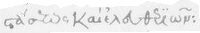

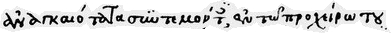

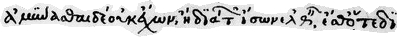

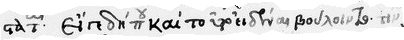

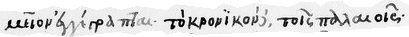

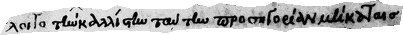

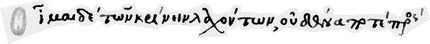

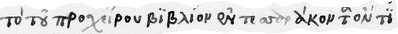

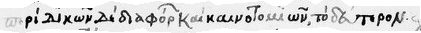

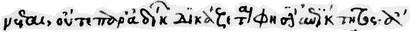

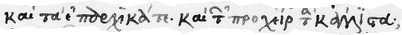

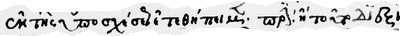

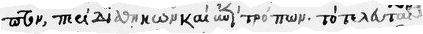

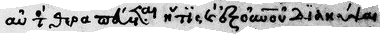

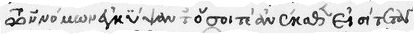

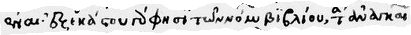

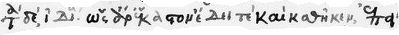

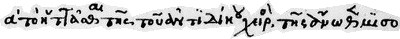

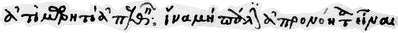

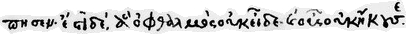

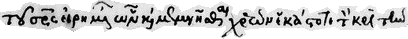

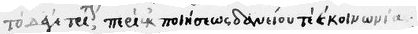

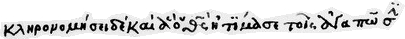

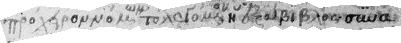

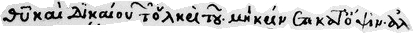

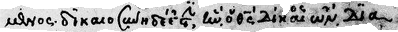

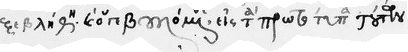

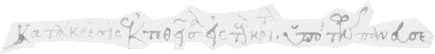

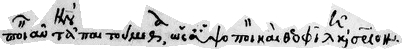

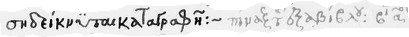

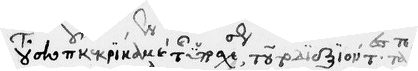

In [6]:
def show_row(row: dict) -> None:
    ops = align_ops(row["gt"], row["pred"])
    mismatches = [(op, a, b) for op, a, b in ops if op != "eq"]
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(row['file'])}</b> &nbsp; "
            f"edits={row['edits']} &nbsp; CER={row['cer']:.2%} &nbsp; "
            f"len={row['ref_len']}</p>"
        )
    )
    display(IPyImage(filename=str(row["path"])))
    display(HTML(format_alignment_html(ops)))
    if mismatches:
        details = []
        for op, a, b in mismatches:
            details.append(f"{op:3s}  {describe_char(a)}  →  {describe_char(b)}")
        display(
            HTML(
                "<pre style='font-size:12px;color:#444'>"
                + "\n".join(details)
                + "</pre>"
            )
        )


print("Closest misses first (fewest edits), then the rest.\n")
for row in sorted(all_ft, key=lambda item: (item["edits"], item["cer"])):
    show_row(row)


## 4. Where the 15% actually is

Group substitutions into diacritic-only (same base letter after NFD strip), punctuation, space, and real letter changes.


In [7]:
subs, dels, ins = Counter(), Counter(), Counter()
bucket = Counter()
bucket_edits = 0

for row in all_ft:
    for op, a, b in align_ops(row["gt"], row["pred"]):
        if op == "eq":
            continue
        bucket_edits += 1
        if op == "sub":
            subs[(a, b)] += 1
            if strip_diacritics(a) == strip_diacritics(b) and a != b:
                bucket["diacritic-only sub"] += 1
            elif a in PUNCT or b in PUNCT:
                bucket["punctuation sub"] += 1
            elif a.isspace() or b.isspace():
                bucket["space sub"] += 1
            else:
                bucket["letter/other sub"] += 1
        elif op == "del":
            dels[a] += 1
            bucket["deletion"] += 1
        else:
            ins[b] += 1
            bucket["insertion"] += 1

print(f"Total edits on val+test: {bucket_edits}\n")
print("Edit buckets")
for name, n in bucket.most_common():
    print(f"  {n:4d}  {n / bucket_edits:6.1%}  {name}")

print("\nTop substitutions (GT → PRED)")
for (a, b), n in subs.most_common(20):
    kind = "diacritic" if strip_diacritics(a) == strip_diacritics(b) else "other"
    print(f"  {n:3d}  {describe_char(a)}  →  {describe_char(b)}   [{kind}]")

print("\nTop deletions (in GT, missing from PRED)")
for char, n in dels.most_common(12):
    print(f"  {n:3d}  {describe_char(char)}")

print("\nTop insertions (extra in PRED)")
for char, n in ins.most_common(12):
    print(f"  {n:3d}  {describe_char(char)}")
#! need to look for beta character


Total edits on val+test: 398

Edit buckets
   152   38.2%  deletion
    96   24.1%  letter/other sub
    66   16.6%  insertion
    63   15.8%  diacritic-only sub
    14    3.5%  punctuation sub
     7    1.8%  space sub

Top substitutions (GT → PRED)
    4  'ς' U+03C2 GREEK SMALL LETTER FINAL SIGMA  →  'ν' U+03BD GREEK SMALL LETTER NU   [other]
    4  'ὸ' U+1F78 GREEK SMALL LETTER OMICRON WITH VARIA  →  'ό' U+03CC GREEK SMALL LETTER OMICRON WITH TONOS   [diacritic]
    3  'ο' U+03BF GREEK SMALL LETTER OMICRON  →  'α' U+03B1 GREEK SMALL LETTER ALPHA   [other]
    3  'ὶ' U+1F76 GREEK SMALL LETTER IOTA WITH VARIA  →  'ι' U+03B9 GREEK SMALL LETTER IOTA   [diacritic]
    3  'Κ' U+039A GREEK CAPITAL LETTER KAPPA  →  'κ' U+03BA GREEK SMALL LETTER KAPPA   [other]
    2  'ι' U+03B9 GREEK SMALL LETTER IOTA  →  'ν' U+03BD GREEK SMALL LETTER NU   [other]
    2  'γ' U+03B3 GREEK SMALL LETTER GAMMA  →  'ι' U+03B9 GREEK SMALL LETTER IOTA   [other]
    2  'ν' U+03BD GREEK SMALL LETTER NU  →  ',' U+002

## 5. GT issues that inflate CER and block exact match

Same kind of catalog as Syriac. The finetuning set is almost clean polytonic Greek. Pretraining still mixes Latin lookalikes into Greek words, and treats several dots as different codec classes.

| Ink / intended letter | Wrong encodings in GT | Why it hurts |
|---|---|---|
| Greek `ο` U+03BF | Latin `o` U+006F | extra charset class; exact match dies even if the letter looks right |
| Greek `Ο` / `Κ` / `Χ` / `Ε` / `Τ` | Latin `O` `K` `X` `E` `T` | same |
| middle dot | `·` U+00B7 vs `·` U+0387 vs `.` U+002E | three classes for one blob |
| breathing / koronis | `᾽` U+1FBD vs `᾿` U+1FBF vs `’` U+2019 | same |


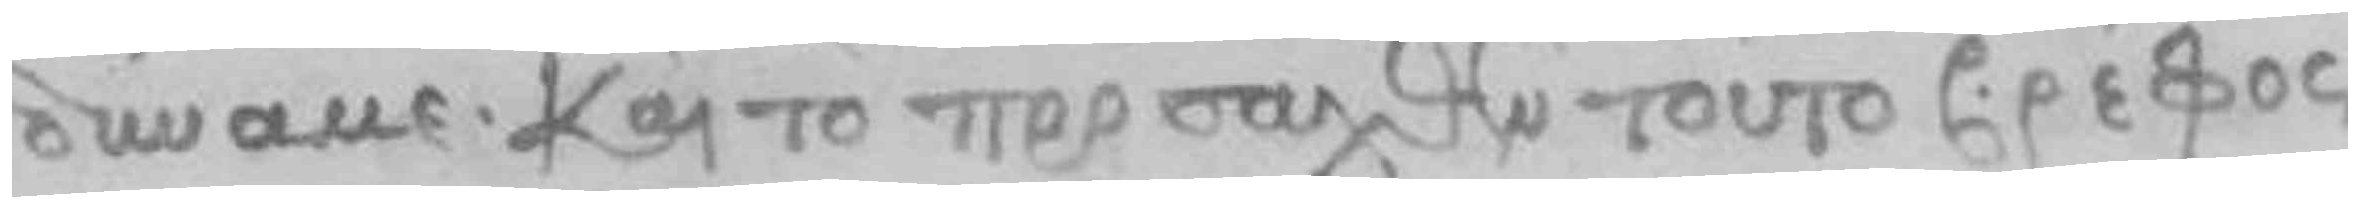

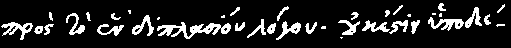

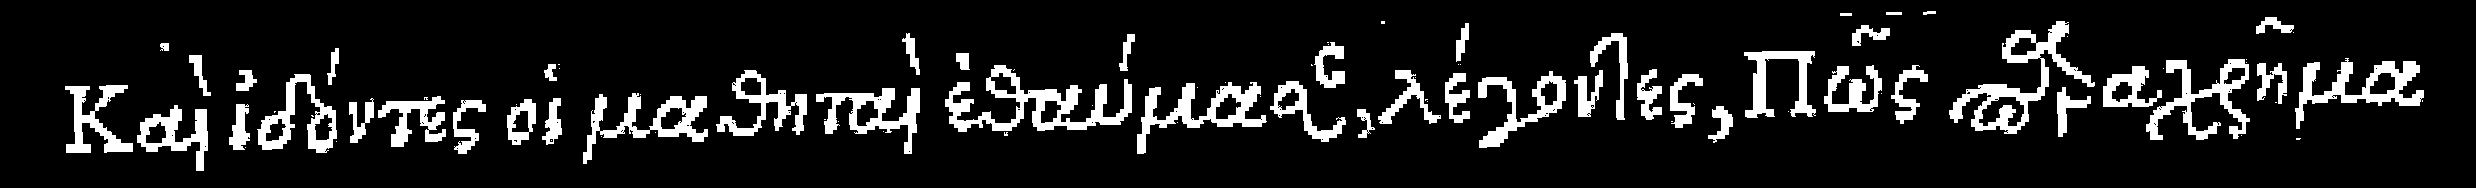

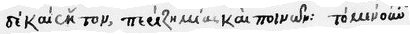

In [8]:
show_sample(
    "dresden_a151_facs_78_020.jpg",
    "Pretrain. Latin o twice in τοῦτο (U+006F) instead of Greek ο (U+03BF).",
)
show_sample(
    "esteban__eparchos_ct_page_002_line_016.png",
    "Pretrain. Latin o at the start of οὐκ.",
)
show_sample(
    "esteban__icdar_nt_ct_page_1404_line_001.png",
    "Pretrain. Latin K in Καὶ. Looks identical to Greek Κ in the crop.",
)
show_sample(
    "Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_10_6.jpg",
    "Finetune train. Was Latin t in tὸ. Now Greek τὸ.",
)


## 6. Three different “dot” classes in pretraining GT

These are not one punctuation mark. If the model predicts the other Unicode dot, CER moves a little and exact match stays 0.


Dot-like characters in Greek GT

finetuning
  train  '.'=32  '·'=89
  val    '.'=8  '·'=11
  test   '.'=4  '·'=7

pretraining
  train  '.'=5743  '·'=5478  '·'=544  '•'=171  '⁛'=316
  val    '.'=691  '·'=618  '·'=69  '•'=41  '⁛'=41
  test   '.'=833  '·'=481  '·'=75  '•'=20  '⁛'=22



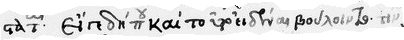

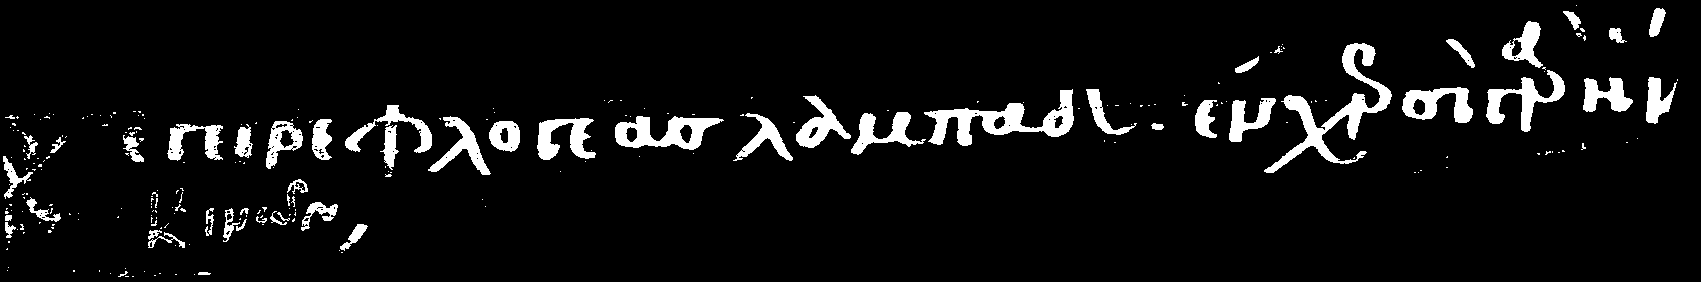

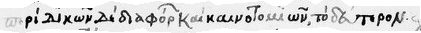

In [9]:
DOTS = {
    ".": "FULL STOP U+002E",
    "·": "MIDDLE DOT U+00B7",
    "·": "GREEK ANO TELEIA U+0387",
    "•": "BULLET U+2022",
    "⁘": "FOUR DOT PUNCTUATION",
    "⁛": "FOUR DOT MARK U+205B",
}

print("Dot-like characters in Greek GT\n")
for partition in ("finetuning", "pretraining"):
    print(partition)
    for split in ("train", "val", "test"):
        counts = Counter()
        path = GREEK / partition / f"gt_{split}.txt"
        for line in path.read_text(encoding="utf-8").splitlines():
            _, text = line.split("\t", 1)
            counts.update(c for c in text if c in DOTS)
        bits = "  ".join(f"{char!r}={counts[char]}" for char in DOTS if counts[char])
        print(f"  {split:5s}  {bits or '(none)'}")
    print()

# One example of each common dot, if present in finetuning val/test or pretraining val.
examples = {
    "·": None,
    "·": None,
    ".": None,
}
for partition, split in (("finetuning", "val"), ("finetuning", "test"), ("pretraining", "val")):
    for name, text, path in load_split(partition, split):
        for char in examples:
            if examples[char] is None and char in text:
                examples[char] = name

for char, name in examples.items():
    if name:
        show_sample(name, f"GT contains {DOTS[char]}. Compare the actual ink to the other dot classes.")


## 7. How to read the numbers

1. **15% CER and 0% exact match can both be true.** On ~50-character lines, 15% CER is several mistakes per line. Exact match needs zero.
2. If section 2 shows a much higher match after **strip diacritics**, the model knows the words and is losing on tonos/varia/breathing.
3. If the jump is after **ignore punctuation**, unify `·` / `·` / `.` in the GT (same policy as Syriac ASCII `.` vs Syriac dots).
4. If match stays 0 even after those, section 4’s letter substitutions are the real remaining error.
5. Pretraining still has Latin `o`/`O`/`K`/`X` inside Greek words. Those belong in a cleanup pass; they should not stay in the codec.


## 8. Pretraining GT catalog

The next sections are the Latin / ASCII / lookalike inventory from the consult. **Latin lookalikes are already rewritten** in `gt_*.txt` (152 rows). **`ß` is now `ϛ`.** **`´` `´` `΄` are now `᾽`.** **`;` is now `;`.** **`ˑ` is now `:`.** **`–` is now `-`.** `.` / `·` / `¬` were left.

`show_gt_issue` shows crop + current GT + codepoints. It does not call Calamari, so the catalog is cheap to step through.


In [10]:
def show_gt_issue(image_name: str, problem: str, highlight: str = "") -> None:
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
    marks = highlight or ""
    marked = []
    for char in gt:
        piece = escape(char)
        if char in marks:
            piece = f"<span style='background:#fd8;padding:0 1px'>{piece}</span>"
        marked.append(piece)
    codes = []
    seen = set()
    for char in gt:
        if char in marks and char not in seen:
            seen.add(char)
            codes.append(f"{char!r} U+{ord(char):04X} {unicodedata.name(char, '?')}")
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px</p>"
            f"<p style='color:#a33'><b>Look at.</b> {escape(problem)}</p>"
        )
    )
    display(IPyImage(filename=str(path)))
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"GT: {''.join(marked)}"
            "</pre>"
            + (f"<pre style='font-size:12px;color:#444'>{escape(chr(10).join(codes))}</pre>" if codes else "")
        )
    )


print("show_gt_issue ready.")

show_gt_issue ready.


## 9. Latin lookalikes — already cleaned

152 pretraining lines had Latin `o O T E X K Y M N I H A` mapped to Greek `ο Ο Τ Ε Χ Κ Υ Μ Ν Ι Η Α`. Finetuning `tὸ` is now `τὸ`. These crops used to be the leaks. GT now has the Greek letter. Check that the ink matches.


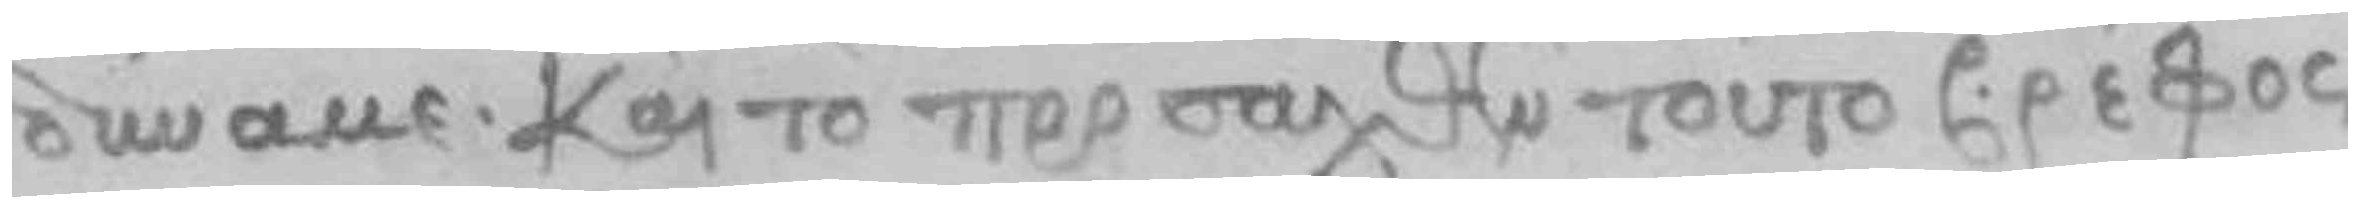

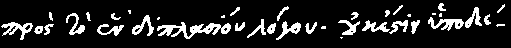

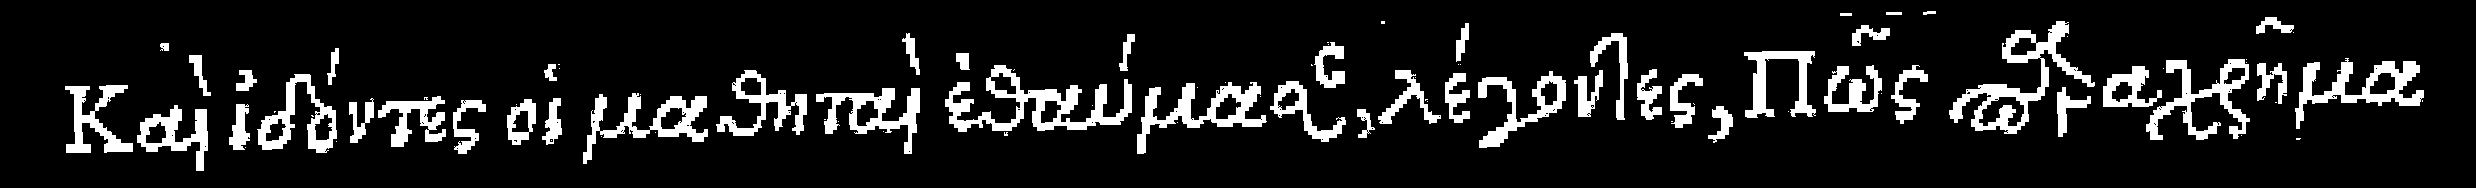

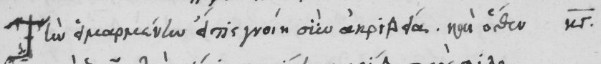

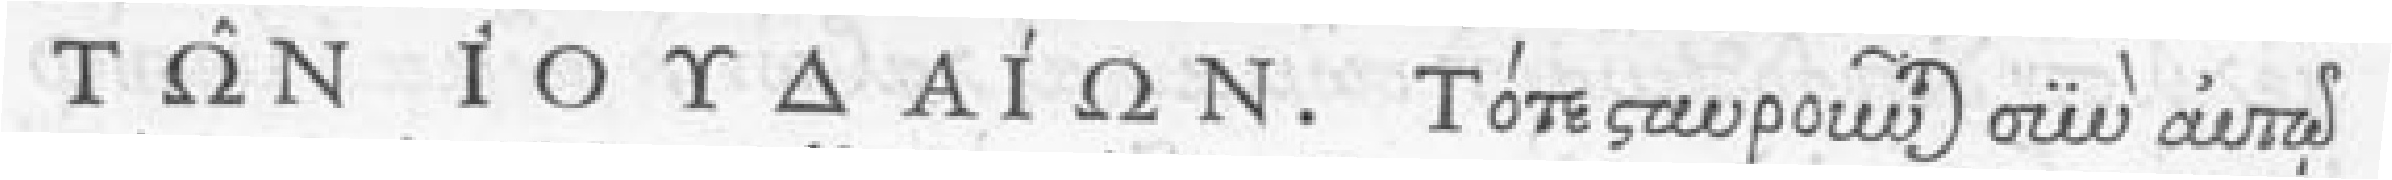

In [11]:
show_gt_issue(
    "dresden_a151_facs_78_020.jpg",
    "Was Latin o in τοῦτο. Now Greek ο U+03BF.",
    highlight="ο",
)
show_gt_issue(
    "esteban__eparchos_ct_page_002_line_016.png",
    "Was Latin o at the start of οὐκ. Now Greek ο.",
    highlight="ο",
)
show_gt_issue(
    "esteban__icdar_nt_ct_page_1404_line_001.png",
    "Was Latin K in Καὶ. Now Greek Κ U+039A.",
    highlight="Κ",
)
show_gt_issue(
    "greek_eparchos_0004504.jpg",
    "Was Latin T in Τὴν. Now Greek Τ U+03A4.",
    highlight="Τ",
)
show_gt_issue(
    "labelled__New_Testament_1550_v1_089_11.png",
    "Was Latin Y in ἸΟΥΔΑΊΩΝ. Now Greek Υ U+03A5.",
    highlight="Υ",
)

## 10. Latin `ß` → stigma `ϛ`

16 Eparchos lines. Printed `ß` is now Greek stigma `ϛ` (numeral 6): `ϛβ´` = 62, `ϛη´` = 68. Each text exists twice (Esteban import + `greek_eparchos_*`).


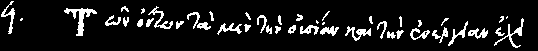

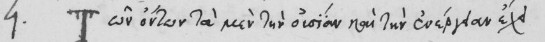

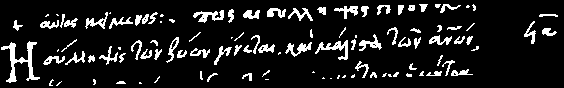

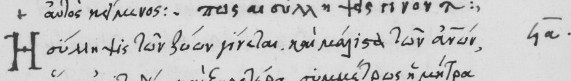

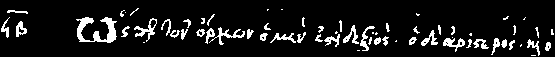

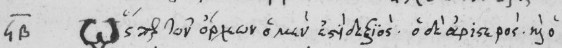

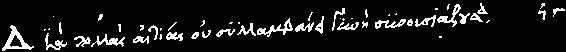

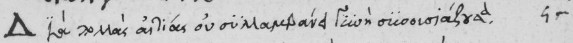

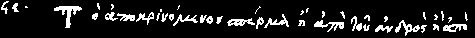

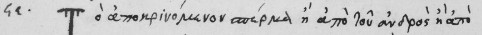

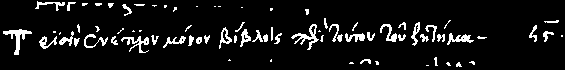

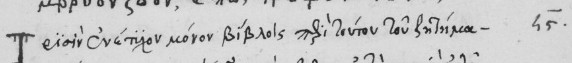

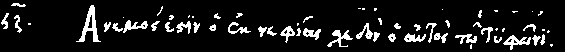

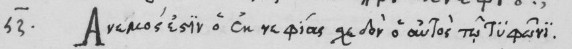

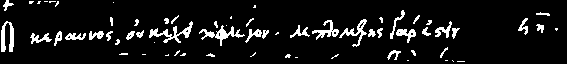

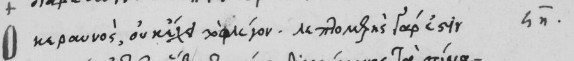

In [12]:
BETA_LINES = [
    ("esteban__eparchos_ct_page_097_line_019.png", "ϛ´. section 6. Pair: greek_eparchos_0009576.jpg"),
    ("greek_eparchos_0009576.jpg", "Same text as Esteban page 097."),
    ("esteban__eparchos_ct_page_098_line_014.png", "ϛα´ = 61. Pair: greek_eparchos_0006388.jpg"),
    ("greek_eparchos_0006388.jpg", "Same text as Esteban page 098."),
    ("esteban__eparchos_ct_page_099_line_010.png", "ϛβ´ = 62. Pair: greek_eparchos_0000765.jpg"),
    ("greek_eparchos_0000765.jpg", "Same text as Esteban page 099."),
    ("esteban__eparchos_ct_page_100_line_005.png", "ϛγ´ = 63. Pair: greek_eparchos_0005179.jpg"),
    ("greek_eparchos_0005179.jpg", "Same text as Esteban page 100."),
    ("esteban__eparchos_ct_page_101_line_017.png", "ϛε´ = 65. Pair: greek_eparchos_0007588.jpg"),
    ("greek_eparchos_0007588.jpg", "Same text as Esteban page 101."),
    ("esteban__eparchos_ct_page_102_line_012.png", "line-final ϛ´. Pair: greek_eparchos_0007563.jpg"),
    ("greek_eparchos_0007563.jpg", "Same text as Esteban page 102."),
    ("esteban__eparchos_ct_page_103_line_006.png", "ϛζ´ = 67. Pair: greek_eparchos_0005065.jpg"),
    ("greek_eparchos_0005065.jpg", "Same text as Esteban page 103."),
    ("esteban__eparchos_ct_page_104_line_002.png", "ϛη´ = 68. Pair: greek_eparchos_0000395.jpg"),
    ("greek_eparchos_0000395.jpg", "Same text as Esteban page 104."),
]

for name, note in BETA_LINES:
    show_gt_issue(name, note, highlight="ϛ")

## 11. Raised dots — four classes for one / two inks

| Char | hits | Proposed |
|---|---:|---|
| `.` U+002E | 7,267 | A1: → `·`  /  A2: keep |
| `·` U+00B7 | 6,577 | → `·` |
| `·` U+0387 | 688 | keep (canonical ano teleia) |
| `•` U+2022 | 232 | → `·` |

Look at whether the ink is a **low** period or a **raised** phrase dot.


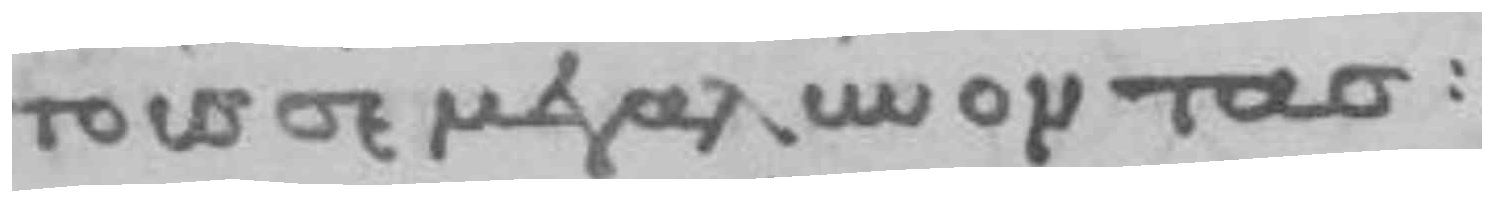

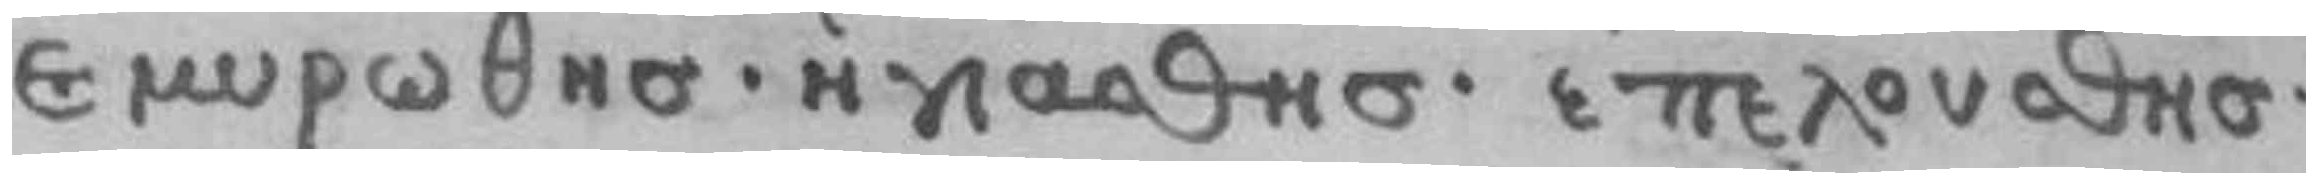

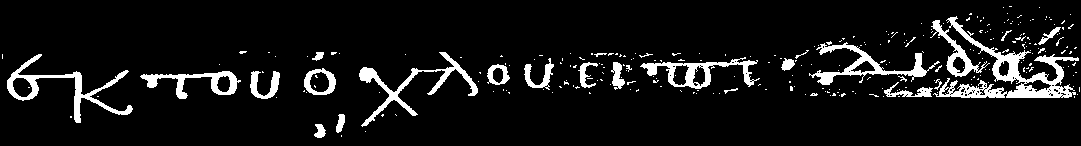

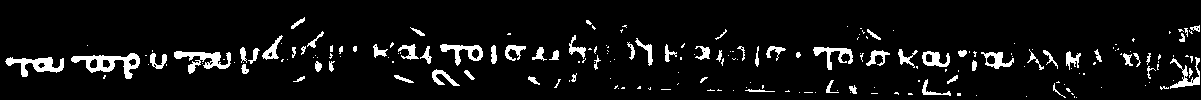

In [13]:
show_gt_issue("dresden_a151_facs_116_018.jpg", "ASCII full stop U+002E. Low or raised in the crop?", highlight=".")
show_gt_issue("dresden_a151_facs_114_000.jpg", "Middle dot U+00B7. Same raised phrase mark as ano teleia?", highlight="·")
show_gt_issue("esteban__bodleian_13_page_021_line_019.png", "Greek ano teleia U+0387 (canonical raised dot).", highlight="·")
show_gt_issue("esteban__bodleian_12_page_052_line_001.png", "Bullet U+2022. Another raised-dot encoding.", highlight="•")

## 12. Question mark — now `;`

ASCII `;` and Greek `;` were the same ink. All question marks are now `;` U+037E. Do not NFC — Unicode turns that back into `;`.


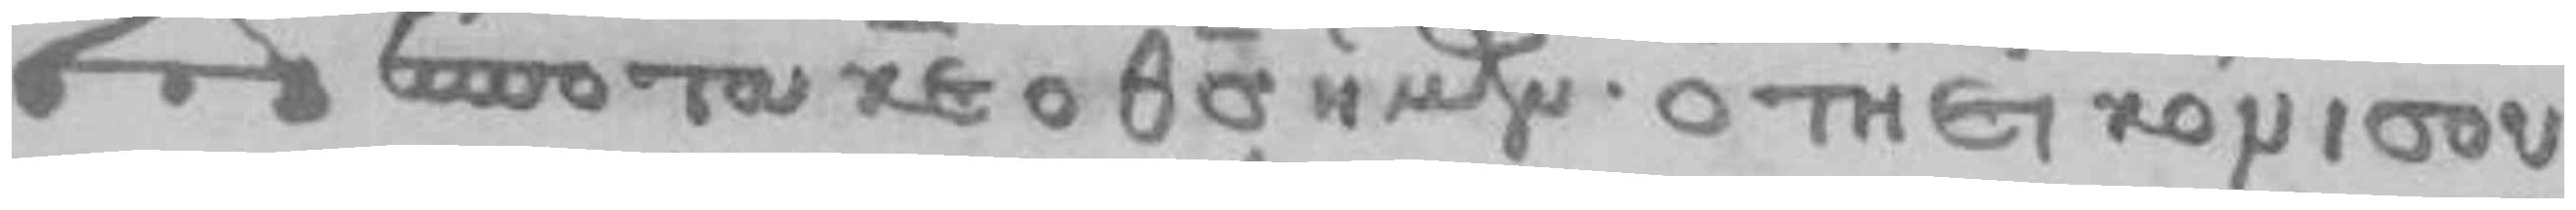

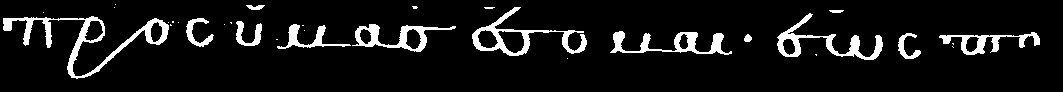

In [14]:
show_gt_issue("dresden_a151_facs_114_004.jpg", "Was ASCII ; . Now Greek ;.", highlight=";")
show_gt_issue("esteban__bodleian_13_page_022_line_010.png", "Already Greek ;. Unchanged.", highlight=";")

## 13. High comma — elision / coronis / spacing breathing

Five encodings of a raised comma. 1,649 + 467 + 278 + 84 + 32 hits. Recommend unify to `᾽` (koronis), or only unify `'` / `’` / `ʼ` and leave `᾿`.


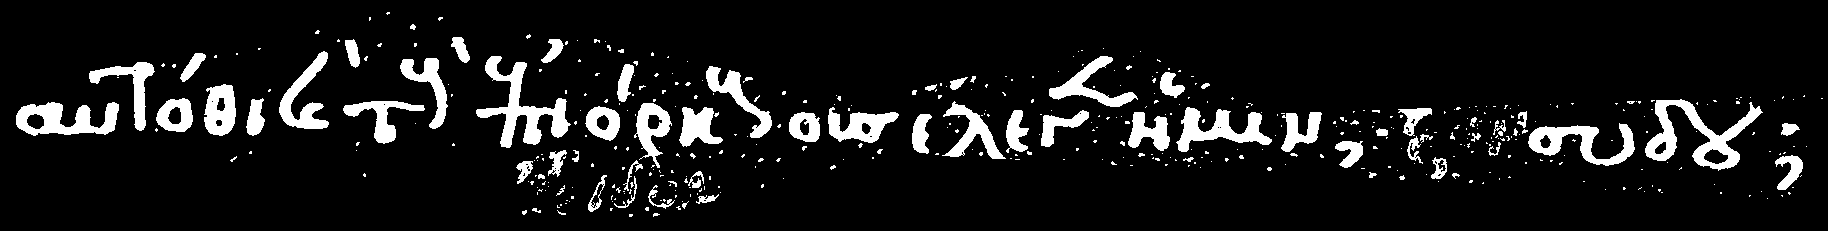

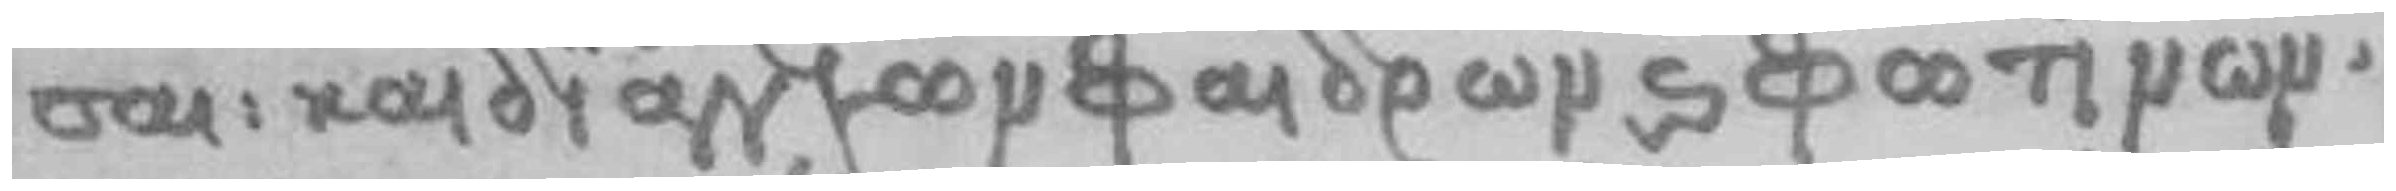

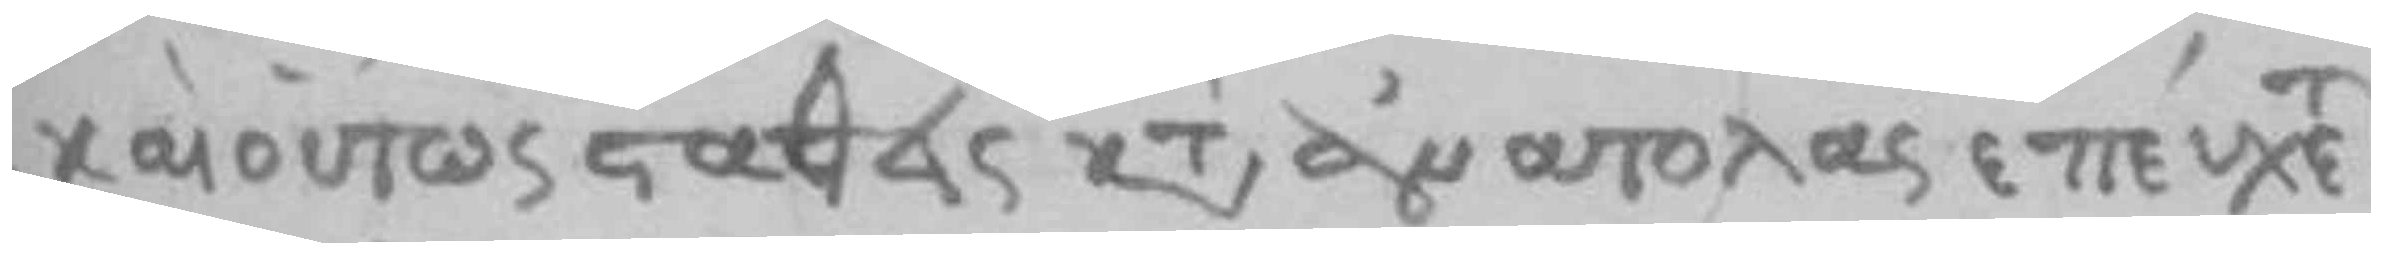

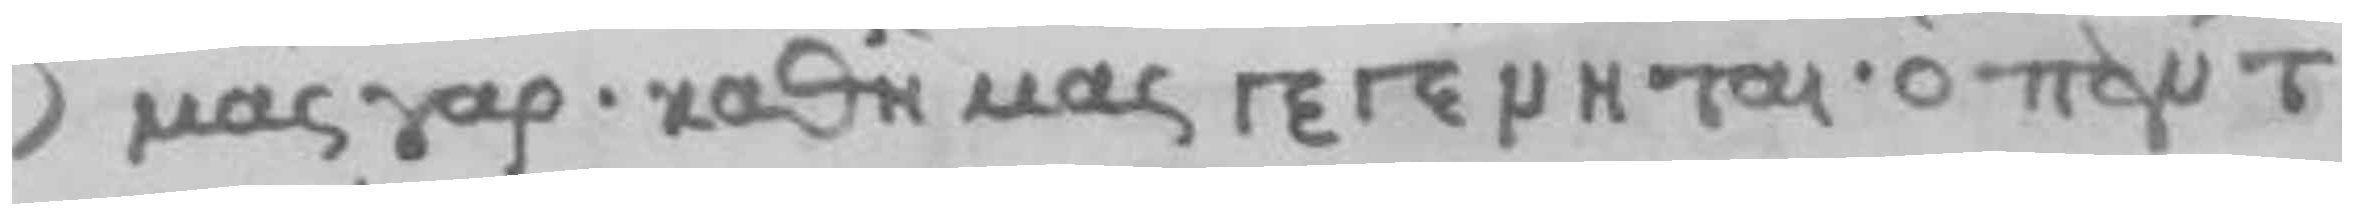

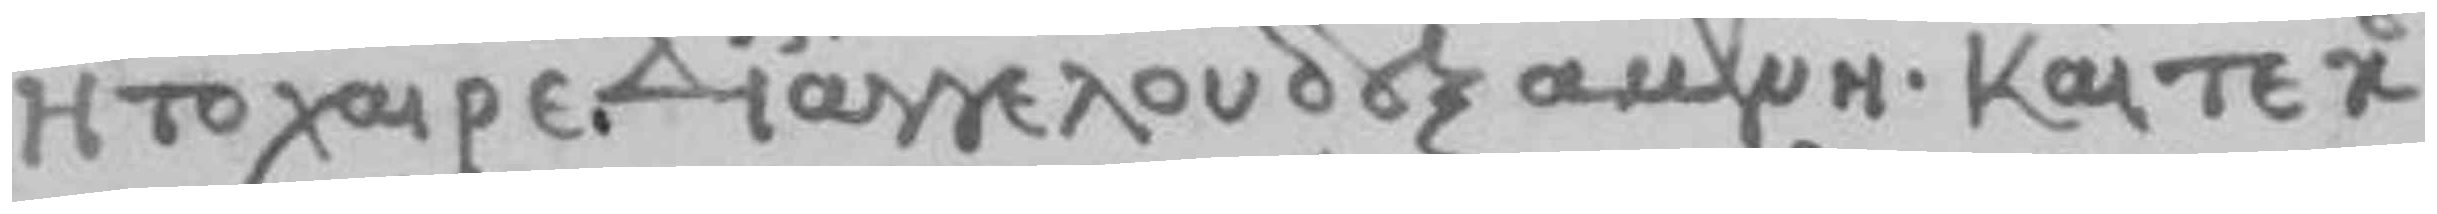

In [15]:
show_gt_issue("esteban__bodleian_14_page_031_line_004.png", "Koronis U+1FBD in δ᾽ / οὔ. Traditional elision mark.", highlight="᾽")
show_gt_issue("dresden_a151_facs_72_014.jpg", "Spacing psili U+1FBF in δι᾿. Same raised comma?", highlight="᾿")
show_gt_issue("dresden_a151_facs_187_008.jpg", "Unicode right quote U+2019 in κατ’.", highlight="’")
show_gt_issue("dresden_a151_facs_118_018.jpg", "ASCII apostrophe U+0027 in καθ'.", highlight="'")
show_gt_issue("dresden_a151_facs_116_016.jpg", "Modifier apostrophe U+02BC in διʼ.", highlight="ʼ")

## 14. Tick / apostrophe — now `᾽`

`´` `´` `΄` (and unused `ʹ`) are the same tick as the apostrophe. They are now koronis `᾽` U+1FBD. Number vs elision is left to context (`α᾽` = 1, `καθ ᾽` = elision).


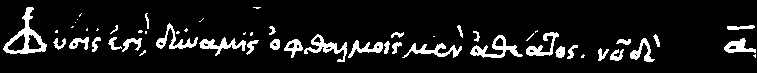

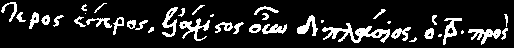

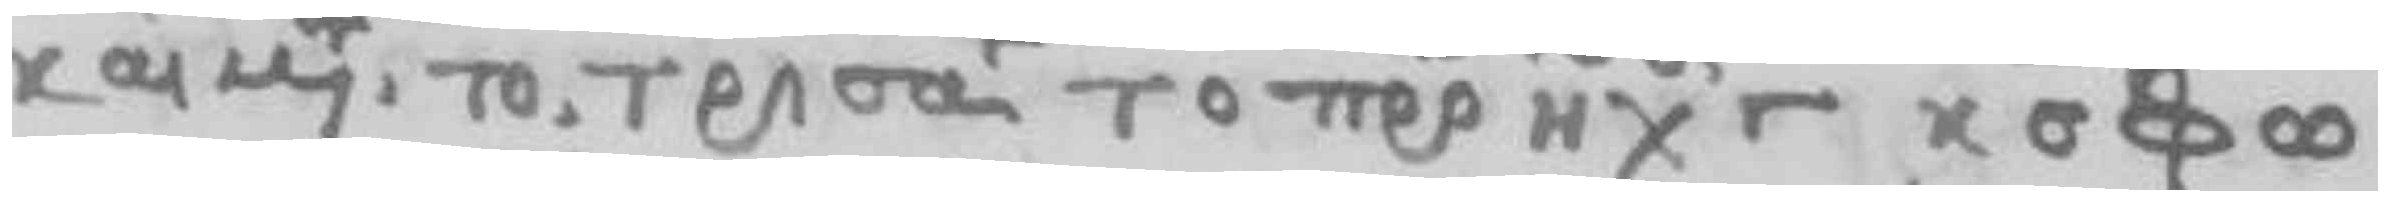

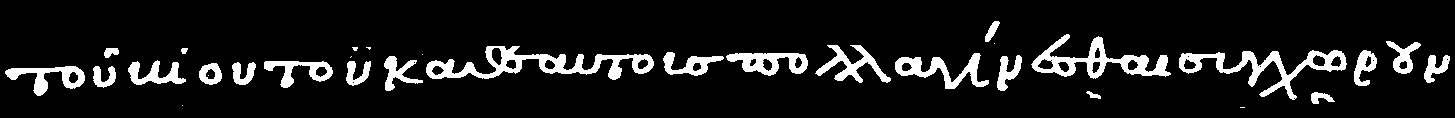

In [16]:
show_gt_issue("esteban__eparchos_ct_page_001_line_004.png", "Was acute α´. Now koronis α᾽ (number 1).", highlight="᾽")
show_gt_issue("esteban__eparchos_ct_page_002_line_017.png", "Was oxia β´. Now koronis β᾽.", highlight="᾽")
show_gt_issue("dresden_a151_facs_121_016.jpg", "Was tonos ἤχος γ΄. Now ἤχος γ᾽.", highlight="᾽")
show_gt_issue("esteban__bodleian_11_page_001_line_002.png", "Was καθ ΄. Same koronis: καθ ᾽ εαυτοὺς.", highlight="᾽")

## 15. Colon and dash unified; `¬` left

`ˑ` is now the two-dot colon `:`. Old `:ˑ` (`::`) is collapsed to one `:`. `–` is now `-`. `¬` is still the end-of-line word-break mark (`κατασκε¬`). `.` and `·` stay as two different stops.


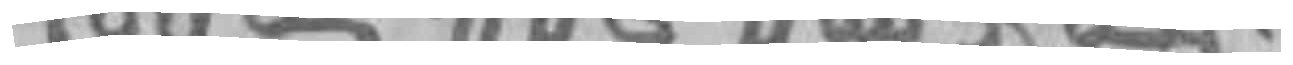

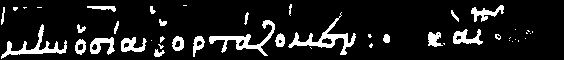

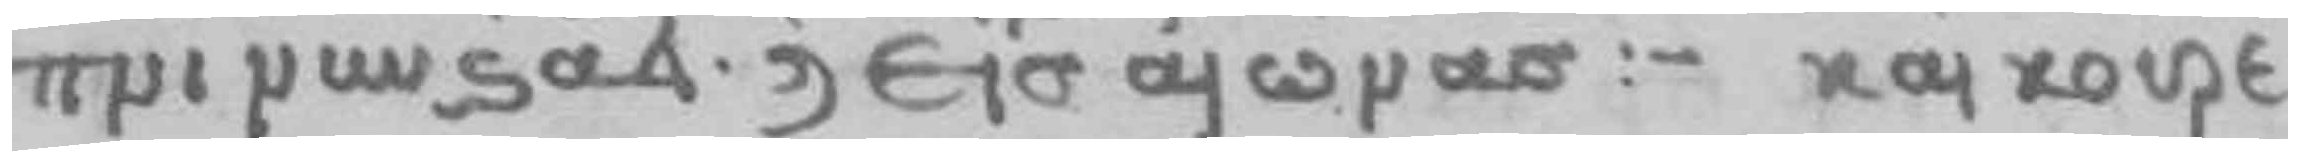

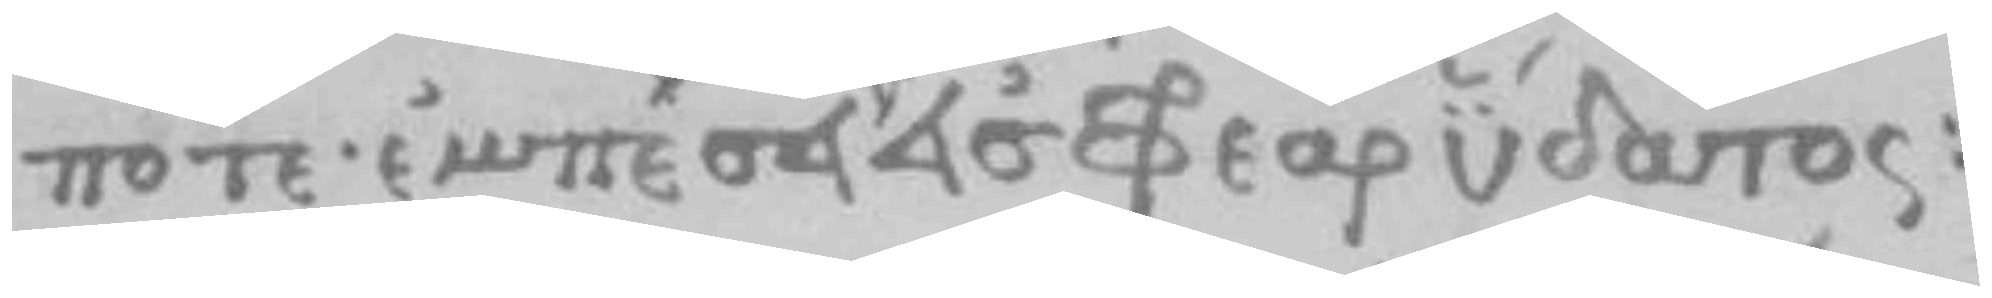

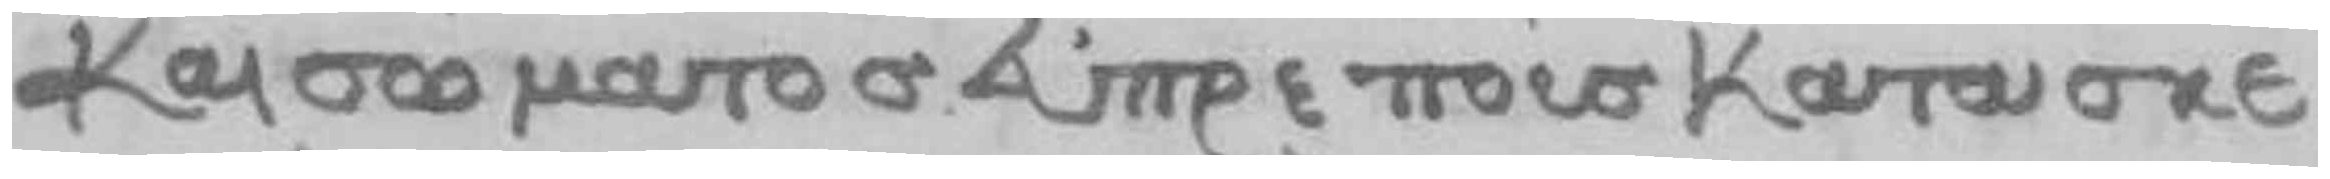

In [17]:
show_gt_issue("dresden_a151_facs_114_002.jpg", "Two-dot colon : (kept).", highlight=":")
show_gt_issue("esteban__monas114_ct_page_003_line_002.png", "Was ˑ. Now two-dot colon :.", highlight=":")
show_gt_issue("dresden_a151_facs_116_006.jpg", "Hyphen in :- (kept).", highlight="-")
show_gt_issue("dresden_a151_facs_187_001.jpg", "Was :–. Now :-.", highlight="-")
show_gt_issue("dresden_a151_facs_114_006.jpg", "¬ left: word continues on the next line.", highlight="¬")

## 16. Editorial apparatus — out of the Latin/punct pass

`°` (702) and `` ` `` / ``` are NT / Esteban apparatus, not lookalike letters. Brackets and other symbols stay until you ask.


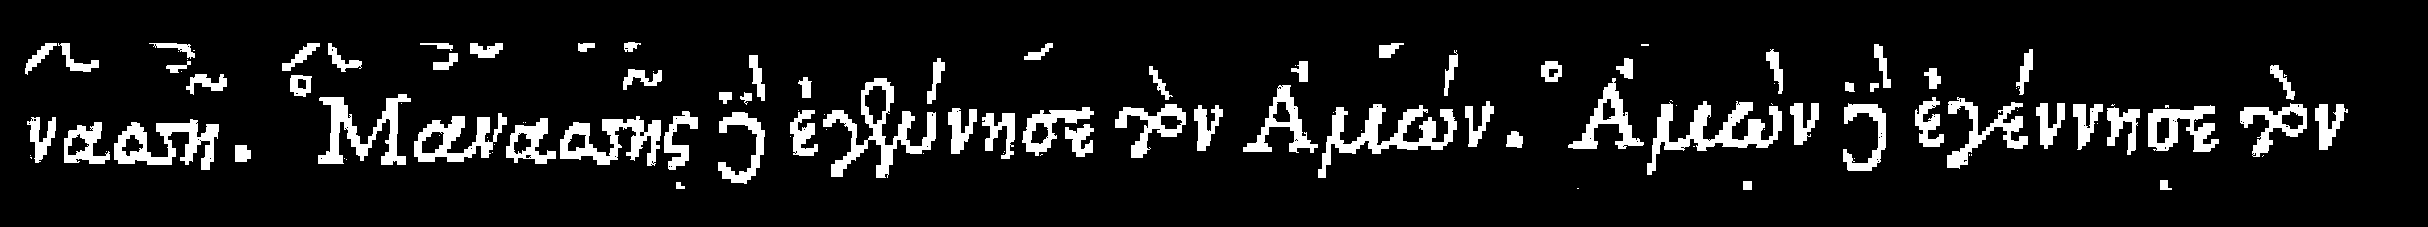

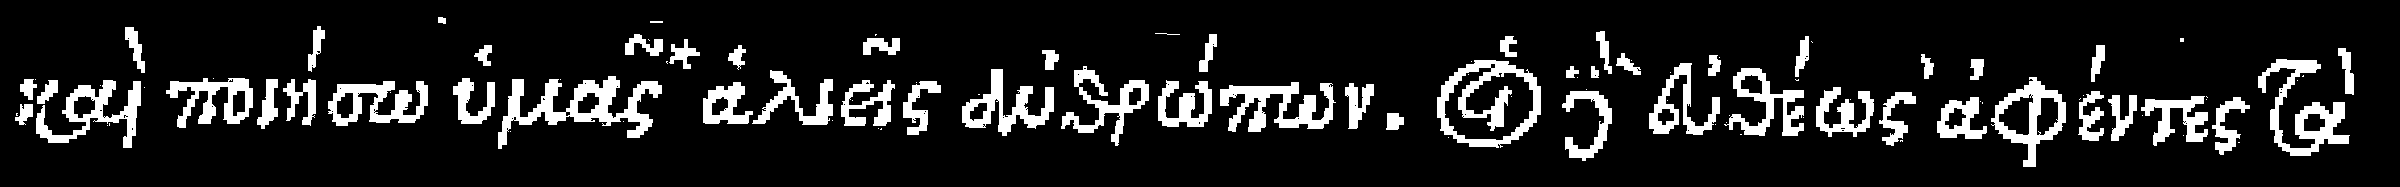

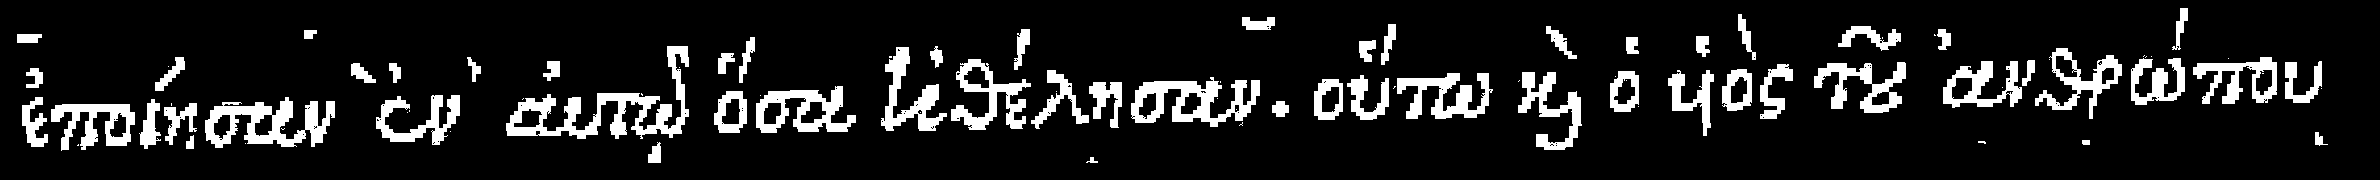

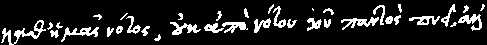

In [18]:
show_gt_issue("esteban__icdar_nt_ct_page_013_line_001.png", "Degree sign U+00B0 in the labelled/Esteban NT. Footnote / apparatus, not a letter.", highlight="°")
show_gt_issue("esteban__icdar_nt_ct_page_210_line_001.png", "ASCII grave U+0060 wrapping a phrase: `εὐθέως᾿. Apparatus.", highlight="`")
show_gt_issue("esteban__icdar_nt_ct_page_1101_line_001.png", "Spacing varia U+1FEF: `ἐν᾿. Same kind of editorial wrap.", highlight="`")
show_gt_issue("esteban__eparchos_ct_page_053_line_008.png", "Spacing varia in καθ` ἡμᾶς — might be a stray grave, not apparatus.", highlight="`")